## Question 1

There are $n^2$ multiplications followed by $n^2-1$ additions. Hence overall $O(n^2)$ time complexity.

However, if addition is intended to be performed digitwise as its own operation*, we must store up to $2n$ digits and add these for each number, hence instead we have $O(n^3)$ time complexity. We could perhaps reduce this by pairing digits with magnitudes in certain ranges, since most digits will always be 0.

*I would assume this is not the intent, but in practice neither time complexity will apply anyway.

## Question 2
It was preferable to write up these questions out of order.

For $n\in\mathbb Z^+$, suppose $f^{(n)}(\alpha)\neq 0$ but $m<n\implies f^{(m)}(\alpha)=0$. Then see Taylor's theorem for $f$ and $f'$ about $\alpha$,
\begin{align*}
    f(x)&=\sum_{r=0}^{n-1}(x-\alpha)^r\frac{f^{(r)}(\alpha)}{r!}+(x-\alpha)^n\frac{f^{(n)}(\xi)}{n!}=\frac {f^{(n)}(\xi)}{n!}(x-\alpha)^n\ ;\\
    f'(x)&=\sum_{r=0}^{n-2}(x-\alpha)^r\frac{f^{(r+1)}(\alpha)}{r!}+(x-\alpha)^{n-1}\frac{f^{(n)}(\xi)}{(n-1)!}=\frac {f^{(n)}(\xi)}{(n-1)!}(x-\alpha)^{n-1}\ .
\end{align*}
Note that $\xi$ is specific to the expanded function and its argument. However, (WLOG $x>\alpha$) $\xi\in [\alpha, x]$. Thus $\xi\rightarrow \alpha$ as $x \rightarrow \alpha$. But as $f\in C^\infty([a,b],\mathbb R)$ we have also $f^{(n)}(\xi)\rightarrow f^{(n)}(\alpha)$.

Now consider the rate of convergence of Newton's method.
\begin{align*}
    \left|\frac{x_{r+1}-\alpha}{x_r-\alpha}\right|&=\left|\frac{x_r-\frac{f(x_r)}{f'(x_r)}-\alpha}{x_r-\alpha}\right|\\
    &=\left|\frac{(x_r-\alpha)f'(x_r)-f(x_r)}{(x_r-\alpha)f'(x_r)}\right|\\
    &=\left|\frac{f^{(n)}(\xi_2)(x_r-\alpha)^n/(n-1)!-f^{(n)}(\xi_1)(x_r-\alpha)^n/n!}{f^{(n)}(\xi_2)(x_r-\alpha)^n/(n-1)!}\right|\\
    &=\left|\frac{nf^{(n)}(\xi_2)-f^{(n)}(\xi_1)}{nf^{(n)}(\xi_2)}\right|\rightarrow \left|\frac{nf^{n}(\alpha)-f^{n}(\alpha)}{nf^{n}(\alpha)}\right|=\frac{n-1}{n}.
\end{align*}
Hence ($\mathbf b$) for $n>1\iff f'(\alpha)=0$ we have linear convergence, and in particular when $f''(\alpha)\neq0$ we have rate of convergence $\frac12$.<br>
Also ($\mathbf c$) when $f''(\alpha)=0\neq f'''(\alpha)$ we have rate of convergence $\frac23$.

For the case $n=1$, we obtain a rate of convergence $0$, suggesting that the order of convergence is super-linear. Thus we investigate further.<br>
For $n\in\mathbb Z_{\geq 2}$, again suppose $f^{(n)}(\alpha)\neq 0$ but $1<m<n\implies f^{(m)}(\alpha)=0$. Then see Taylor's theorem for $f$ and $f'$ about $\alpha$,
\begin{align*}
    f(x)&=(x-\alpha)f'(\alpha) + (x-\alpha)^n\frac{f^{(n)}(\xi)}{n!}\ ;\\
    f'(x)&=f'(\alpha) + (x-\alpha)^{n-1}\frac{f^{(n)}(\xi)}{(n-1)!}\ .
\end{align*}
Now see the order and rate of convergence.
\begin{align*}
    \left|\frac{x_{r+1}-\alpha}{(x_r-\alpha)^n}\right|&=\left|\frac{x_{r}-\alpha-\frac{f(x_n)}{f'(x_r)}}{(x_r-\alpha)^n}\right|\\
    &=\left|\frac{(x_r-\alpha)f'(x_r)-f(x_r)}{(x_r-\alpha)^nf'(x_r)}\right|\\
    &=\left|\frac{(x_r-\alpha)(f'(\alpha) + (x-\alpha)^{n-1}\frac{f^{(n)}(\xi_2)}{(n-1)!})-\left((x_r-\alpha)f'(\alpha)+(x-\alpha)^n\frac{f^{(n)}(\xi_1)}{n!}\right)}{(x_r-\alpha)^nf'(x_r)}\right|\\
    &=\frac{1}{|f'(x_r)|}\left|\frac1{(n-1)!}f^{(n)}(\xi_2)-\frac1{n!}f^{(n)}(\xi_1)\right|\\
    &\rightarrow \frac{1}{n!|f'(\alpha)|}\left|nf^{(n)}(\alpha)-f^{(n)}(\alpha)\right|=\frac{n-1}{n!}\left|\frac{f^{(n)}(\alpha)}{f'(\alpha)}\right|.
\end{align*}
Hence we have order of convergence $n$ with rate as above.

Thereby, ($\mathbf a$) we have at least quadratic convergence and in particular ($\mathbf d$) if $f''(\alpha)=0\neq f'''(\alpha)$ we have order of convergence $n=3$.

Finally, an additional edge case. When $f^{(n)}(\alpha)=0$ for all $n>1$ the methods above do not provide an answer. Indeed we have $f(x)=x$ with instant convergence, the non-analytic $f(x)=\exp(-\frac1{x^2})$, which exhibits (I conjecture) sublinear convergence, and $f(x)=x+\exp(-\frac1{x^2})$ which exhibits superlinear convergence. From this I conjecture convergence order still follows the pattern dependent on $f'(\alpha)$ found prior, but with sublinear or 'super-super linear' convergence.

## Question 3

In [24]:
import sympy as sy
import numpy as np
import matplotlib.pyplot as plt
import math #factorial

# doesn't currently work w/ what I'm using to do Jupyter.
#import scienceplots
#plt.style.use(["science"])

sy.init_printing()

x = sy.symbols("x", real=True)
def NewtonRaphson(x0, f, x=x, err=10**-8, print_all=False, return_iterations=False, maxIter = 10**3):
    """
        Performs Newton-Raphson iteration on sympy function f(x), initial state x0.
        Halts on |f(x)| < err. Returns final x.
        
        print_all : prints x, f(x) for each iteration step
        return_iterations : instead returns a list of tuples (x,f(x)) for each step
    """
    fx = sy.N(f.subs({x:x0}))
    # sympy N used to prevent weird edge cases where the program outputs fractions which can render output hard to read.
    if return_iterations:
        iterlist = [(x0, fx)]
    dx = f/sy.diff(f, x) # unsure if its better to find f/df and f, or find df and f then calculate f/df.
    iter = 0
    while abs(fx) >= err:
        if print_all:
            print(f"Iteration {iter}, x = {x0}, f(x) = {fx}.")
        x0 -= sy.N(dx.subs({x:x0})) 
        fx = sy.N(f.subs({x:x0}))
        iter += 1
        if return_iterations:
            iterlist += [(x0, fx)]

        if iter > maxIter:
            # error encountered
            if print_all:
                print("Failed Convergence")
            return False, False
    
    if print_all:
        print(f"Terminated at iteration {iter}, x = {x0} with f(x) = {fx}.")
    
    if return_iterations:
        return iterlist
    else:
        return x0

# Based on your H1.2 model solutions.
def ConvergenceRateDisplay(sequence, limit):
    """
        Finds order and rate of convergence.
        Plots regression line with data.
    """
    errors = abs(sequence - limit)
    log_errors = np.log(errors)
    plt.scatter(errors[:-1],errors[1:], label="Error Ratios", color="green")
    
    polyfit = np.polynomial.Polynomial.fit(log_errors[:-1],log_errors[1:], deg=1)
    axis = np.linspace(log_errors[0], log_errors[-2], 100)
    plt.loglog(np.exp(axis), np.exp(polyfit(axis)), linestyle='dashed', color="orange", label="Error Ratio Regression")
    
    plt.grid()
    plt.legend()
    plt.xlabel("$n$th Error")
    plt.ylabel("$(n+1)$st Error")
    
    (r, q) = polyfit.convert().coef
    print(f"Found order of convergence {q} with rate {np.exp(r)}.")
    plt.show()

# based on Q2's results
def ExpectedConvergence(limit, f, x=x, print_all=False):
    """
        Finds the expected order and rate of convergence of Newton-Raphson on function f(x) at the provided limit.
        Returns (rate, order).
        
        Required assumptions:
        - the method converges to the given limit.
        - f is sufficiently differentiable: the largest derivative found within must be continuous.

        Will error if the function lacks a non-zero (2+) order derivative.
    """
    fd = sy.diff(f, x)
    fd_1 = fd.subs({x:limit})
    if print_all:
        prettyDeriv = sy.pretty(fd)
        print("Derivative 1: " + prettyDeriv + f"; evaluates to {fd_1}.")

    # find next non-zero derivative
    fd_eval = 0
    err = 10**-10
    n = 1
    while abs(fd_eval) < err:
        n += 1
        fd = sy.diff(fd, x)
        fd_eval = fd.subs({x:limit})
        if print_all:
            prettyDeriv = sy.pretty(fd)
            print(f"Derivative {n}: " + prettyDeriv + f"; evaluates to {fd_eval}.")

    if abs(fd_1) < err:
        (r, q) = ((n-1)/n, 1)
    else:
        (r, q) = (abs( ((n-1)*fd_eval) / (math.factorial(n) * fd_1) ), n)
    if print_all:
        print(f"Expected convergence has order {q} with rate {r}.")
    return (r,q)

### (a)

In [25]:
f1 = sy.sin(x) * sy.sinh(x)
sy.pretty_print(f1)
(r,q) = ExpectedConvergence(0,f1,print_all=True)

sin(x)⋅sinh(x)
Derivative 1: sin(x)⋅cosh(x) + cos(x)⋅sinh(x); evaluates to 0.
Derivative 2: 2⋅cos(x)⋅cosh(x); evaluates to 2.
Expected convergence has order 1 with rate 0.5.


In [26]:
iterations = NewtonRaphson(0.5, f1, print_all=True, return_iterations=True)

Iteration 0, x = 0.5, f(x) = 0.249826397500462.
Iteration 1, x = 0.249652087466031, f(x) = 0.0623234746827269.
Iteration 2, x = 0.124815267001593, f(x) = 0.0155788088656164.
Iteration 3, x = 0.0624072969122087, f(x) = 0.00389467005148684.
Iteration 4, x = 0.0312036379380706, f(x) = 0.000973667010313943.
Iteration 5, x = 0.0156018186403475, f(x) = 0.000243416744726039.
Iteration 6, x = 0.00780090930990223, f(x) = 0.0000608541860588154.
Iteration 7, x = 0.00390045465463013, f(x) = 0.0000152135465127867.
Iteration 8, x = 0.00195022732730504, f(x) = 0.00000380338662816673.
Iteration 9, x = 0.000975113663652204, f(x) = 9.50846657041214E-7.
Iteration 10, x = 0.000487556831826092, f(x) = 2.37711664260296E-7.
Iteration 11, x = 0.000243778415913046, f(x) = 5.94279160650740E-8.
Iteration 12, x = 0.000121889207956523, f(x) = 1.48569790162685E-8.
Terminated at iteration 13, x = 0.0000609446039782615 with f(x) = 3.71424475406712E-9.


Found order of convergence 0.9999301525178903 with rate 0.4997734484604637.


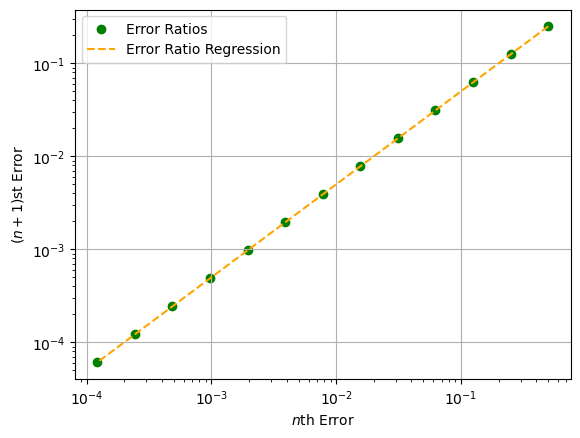

In [27]:
sequence = np.array(list(zip(*iterations))[0], dtype='float64')
ConvergenceRateDisplay(sequence, 0)

### (b)

In [28]:
f2 = x - sy.sin(x)
sy.pretty_print(f2)
(r,q) = ExpectedConvergence(0,f2,print_all=True)

x - sin(x)
Derivative 1: 1 - cos(x); evaluates to 0.
Derivative 2: sin(x); evaluates to 0.
Derivative 3: cos(x); evaluates to 1.
Expected convergence has order 1 with rate 0.6666666666666666.


In [29]:
iterations = NewtonRaphson(0.5, f2, print_all=True, return_iterations=True)

Iteration 0, x = 0.5, f(x) = 0.0205744613957970.
Iteration 1, x = 0.331931939489110, f(x) = 0.00606182039667691.
Iteration 2, x = 0.220880000703620, f(x) = 0.00179167179015990.
Iteration 3, x = 0.147133388298258, f(x) = 0.000530288685770847.
Iteration 4, x = 0.0980535072831218, f(x) = 0.000157046900312222.
Iteration 5, x = 0.0653585264297644, f(x) = 0.0000465224679870313.
Iteration 6, x = 0.0435692483194566, f(x) = 0.0000137831261437515.
Iteration 7, x = 0.0290452465217024, f(x) = 0.00000408371693587373.
Iteration 8, x = 0.0193632254136515, f(x) = 0.00000120996751822727.
Iteration 9, x = 0.0129087362753318, f(x) = 3.58505907177911E-7.
Iteration 10, x = 0.00860580028281161, f(x) = 1.06223579144499E-7.
Iteration 11, x = 0.00573719310693232, f(x) = 3.14736012816189E-8.
Terminated at iteration 12, x = 0.00382479330636104 with f(x) = 9.32550466925877E-9.


Found order of convergence 0.9993888712527985 with rate 0.665057125533504.


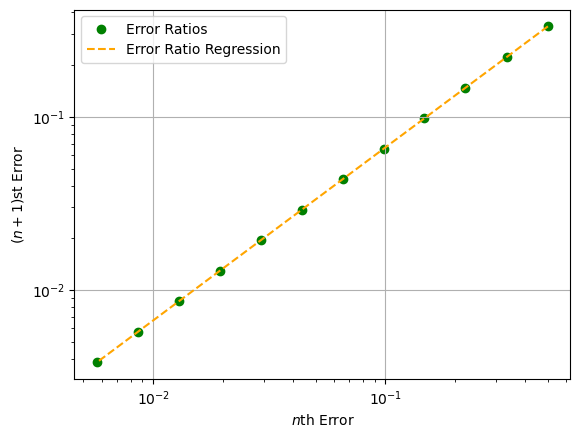

In [30]:
sequence = np.array(list(zip(*iterations))[0], dtype='float64')
ConvergenceRateDisplay(sequence, 0)

### (c)

In [31]:
f3 = x * sy.cos(x)
sy.pretty_print(f3)
(r,q) = ExpectedConvergence(0,f3,print_all=True)

x⋅cos(x)
Derivative 1: -x⋅sin(x) + cos(x); evaluates to 1.
Derivative 2: -x⋅cos(x) - 2⋅sin(x); evaluates to 0.
Derivative 3: x⋅sin(x) - 3⋅cos(x); evaluates to -3.
Expected convergence has order 3 with rate 1.


In [32]:
iterations = NewtonRaphson(0.5, f3, print_all=True, return_iterations=True)

Iteration 0, x = 0.5, f(x) = 0.438791280945186.
Iteration 1, x = -0.187901019994554, f(x) = -0.184593676931974.
Iteration 2, x = 0.00696212297139120, f(x) = 0.00696195424099750.
Iteration 3, x = -3.37483961510184E-7, f(x) = -3.37483961510164E-7.
Terminated at iteration 4, x = 3.84870595408673E-20 with f(x) = 3.84870595408673E-20.


Found order of convergence 3.017075488928315 with rate 1.2327070495847399.


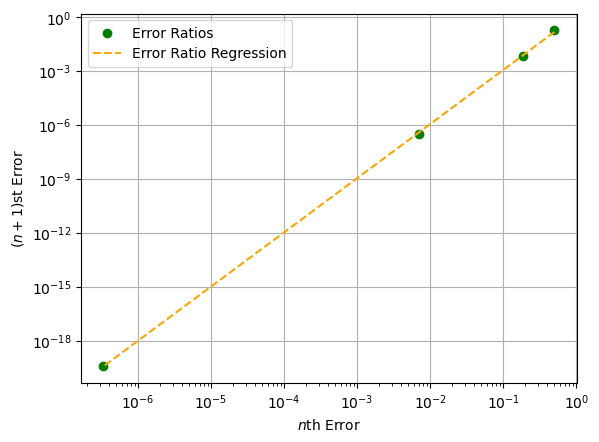

In [33]:
sequence = np.array(list(zip(*iterations))[0], dtype='float64')
ConvergenceRateDisplay(sequence, 0)